## LangGraph Basics

### 1. Building a Simple Workflow or graph using LangGraph

#### State
The State schema serves as the input schema for all nodes and edges in the graph

In [2]:
from typing_extensions import TypedDict

class State(TypedDict): 
    graph_info : str

#### Nodes

Nodes are python functions

The first positional argument in the state, as defined above

Because the state is a TypedDict with schema as defined above, each node can access the key, graph_state, with state `['graph_state']`

Each node returns a new value of the state key graph_state

In [ ]:
def start_play(state: State):
    print("Start_play node has been called")
    return {"graph_info": state['graph_info'] + "I am planning to play"}

def cricket(state:State):
    print("My Cricket Node has been called")
    return {"graph_info": state['graph_info'] + "I am planning to play cricket"}

def badmintton(state:State):
    print("My Badminton Node has been called")
    return {"graph_info": state['graph_info'] + "I am planning to play Badmintton"}

In [4]:
import random
from typing import Literal

def random_play(state:State) -> Literal['cricket', 'badmintton']:
    graph_info = state['graph_info']

    if random.random() > 0.5:
        return "cricket"
    else:
        return "badmintton"

### Graph Construction

Now, we build the graph from out components defined above.

The StateGraph class is the graph class that we can use

First, we initialize a StateGraph with the State class we defined above.

Then, we add our nodes and edges

We use the START NODE, a special node that sends user input to the graph, to indicate where to start our graph

The END NODE is a special node that represents a terminal node.

Finally we compile our graph to perform a few basic checks on the graph structure

We can visualize the graph as a mermaid diagram.

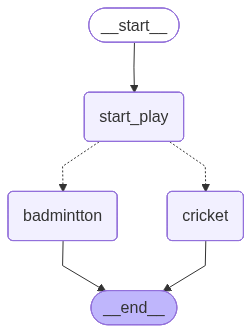

In [5]:
from IPython.display import Image, display
from langgraph.graph import StateGraph, START, END

## Build Graph
graph = StateGraph(State)

## Adding the nodes
graph.add_node("start_play", start_play)
graph.add_node("cricket", cricket)
graph.add_node("badmintton", badmintton)

## Schedule the flow of the graph
graph.add_edge(START, "start_play")
graph.add_conditional_edges("start_play", random_play)
graph.add_edge("cricket", END)
graph.add_edge("badmintton", END)

## Compile the Graph
graph_builder = graph.compile()

## View the Graph
display(Image(graph_builder.get_graph().draw_mermaid_png()))

### Graph Invocation

In [8]:
graph_builder.invoke({"graph_info": "Hey My name is Navneet"})

Start_play node has been called
My Badminton Node has been called


{'graph_info': 'Hey My name is NavneetI am planning to playI am planning to play Badmintton'}